In [1]:
using QuadGK,LaTeXStrings,LinearAlgebra,BenchmarkTools;
using Plots,CSV,DataFrames;
import NLsolve,Roots;
import Optim;

In [2]:
gr(frame=:box, minorticks=5, size=(400,300));

In [2]:
# pyplot(frame=:box, minorticks=5, size=(500,350), fontfamily="serif",titlefontsize=11
#     ,guidefontsize=12,tickfontsize=11,legendfontsize=9,
#     bg_color_legend = RGBA(1,1,1,0.15), markerstrokecolor= :auto);

In [3]:
include("./libs/constants.jl");
include("./libs/pwa.jl");
include("./libs/potentials.jl");

In [4]:
λf(x, y, z) = x^2 + y^2 + z^2 - 2 * x * y - 2 * x * z - 2 * y * z
q0f(E, m1, m2, m3, m4) = abs(m3^2 - m4^2 - m1^2 + m2^2) / (2 * E)
μf(m1, m2) = m1 * m2 / (m1 + m2)

# redefine sqrt so that its cut is along the positive x axis
function xsqrt(x)
    imag(x) >=0 ? sqrt(x+0im) : -sqrt(x-0im)
end
xsqrt1(x)= (imag(x)<0&&real(x)>0) ? -xsqrt(x) : xsqrt(x)

xsqrt1 (generic function with 1 method)

In [5]:
# using LoopTools;

In [6]:
C0(3.875^2,(mDn+mπc+0.001)^2,mDn^2,mDsn^2,mDc^2,mπn^2)

UndefVarError: UndefVarError: `C0` not defined

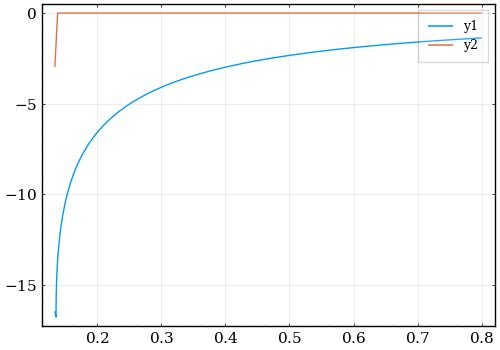

In [9]:
let
    f(mex)=C0(3.875^2,(mDn+mπc+0.001)^2,mDn^2,mDsn^2,mDc^2,mex^2)
    plot(m->real(f(m)),0.134,0.8)
    plot!(m->imag(f(m)),0.134,0.8)
end

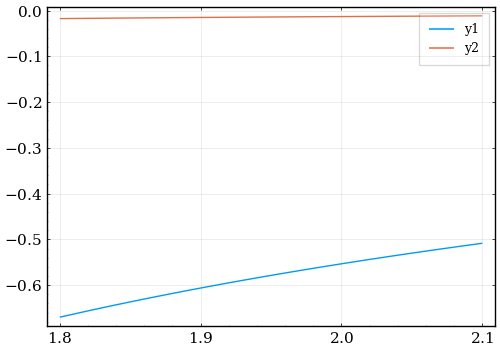

In [10]:
let
    f(mex)=C0(3.872^2,(2*mπc+0.001)^2,3.01^2,mDn^2,mDsn^2,mex^2)
    plot(m->real(f(m)),1.8,2.1)
    plot!(m->imag(f(m)),1.8,2.1)
end

In [5]:

#https://github.com/fkguo/IMinuit.jl/blob/master/src/Data.jl
# check whether the data are valid for a fit
function check_data(xdata, ydata, errdata)
    if any(ismissing, xdata) || any(ismissing, ydata) || any(ismissing, errdata)
        error("Error: Data contain `missing` values.")
    end
    if any(isinf, xdata) || any(isinf, ydata) || any(isnan, xdata) || any(isnan, ydata) || any(isnan, errdata)
        error("Error: Data contain `Inf` or `NaN` values.")
    end
    if any(iszero, errdata)
        error("Error: Data contain 0 in the errors.")
    end
end

"""
    Data(x::T, y::T, err::T) where {T<:Vector{Real}}
    Data(df::DataFrame)
Fields: `x, y, err, ndata`
This defines a type for data with three columns:` x, y, err`; `ndata` is the number of data rows.
Different `Data` sets can be concatenated as `vcat(dat1, dat2, dat3)`.
Only symmetric errors (of `y`) are supported.
"""
struct Data
    x::Vector{Float64}
    y::Vector{Float64}
    err::Vector{Float64}
    ndata::Int
    function Data(x, y, err) # Data(x::Vector{T}, y::Vector{T}, err::Vector{T}) where {T<:Real}
        check_data(x, y, err)
        ndata = length(x)
        new(x, y, err, ndata)
    end
end

Data(df::DataFrame) = Data(df[:,1], df[:,2], df[:,3])

import Base.vcat, Base.getindex
vcat(dat1::Data, dat2::Data) = Data(vcat(dat1.x, dat2.x), vcat(dat1.y, dat2.y), vcat(dat1.err, dat2.err))
vcat(dat1::Data, dat...) = reduce(vcat, [dat1, dat...])
getindex(data::Data, in) = Data(map(x-> getindex(x, in), (data.x, data.y, data.err))...)

"""
    @plt_data(data, kws...)
    @plt_data!(data, kws...)
Convenient mascros to make an errorbar plot of the `data`; all combinations of
keyword settings for `scatter` in `Plots` can be used for the optional arguments `kws...`
"""
macro plt_data(data, kws...)
    _plt = quote
        if isempty($kws)
            Plots.scatter($data.x, $data.y, yerror = $data.err,
            xlab = "x", ylab = "y", label = "Data")
        else
            Plots.scatter($data.x, $data.y, yerror = $data.err; $(kws...) )
        end
    end
    return esc(_plt)
end
macro plt_data!(data, kws...)
    _plt = quote
        if isempty($kws)
            Plots.scatter!($data.x, $data.y, yerror = $data.err,
            xlab = "x", ylab = "y", label = "Data")
        else
            Plots.scatter!($data.x, $data.y, yerror = $data.err; $(kws...) )
        end
    end
    return esc(_plt)
end

@doc raw"""
    chisq(dist::Function, data, par; fitrange = ())
defines the ``\chi^2`` function: `fun` the function to be fitted to the data given by `data`.
The parameters are collected into `par`, given as an array or a tuple.
* `data` can be either given as the `Data` type, or of the form `(xdata, ydata [, err])`.
If no `err` is given explicitly, the errors are assumed to be 1 for all data points.
* `fitrange`: default to the whole data set; may given as, e.g., `2:10`,
which means only fitting to the 2nd to the 10th data points.
"""
function chisq(dist::Function, data::Data, par; fitrange = ())
    fitrange = (isempty(fitrange) ? (1:data.ndata) : fitrange)
    # __dist__(x, par) = (length(func_argnames(dist)) > 2 ? dist(x, par...) : dist(x, par) )
    res = 0.0
    @simd for i = fitrange[1]:fitrange[end]
        @inbounds res += ( (data.y[i]- dist(data.x[i], par))/data.err[i] )^2
    end
    return res
end
# function chisq(dist::Function, data::Data, par::Tuple; fitrange = ())
#     fitrange = (isempty(fitrange) && 1:data.ndata)
#     res = 0.0
#     @simd for i = fitrange
#         @inbounds res += ( (data.y[i]- dist(data.x[i], par))/data.err[i] )^2
#     end
#     return res
# end
function chisq(dist::Function, data, par; fitrange = ())
    _x = data[1]; _y = data[2]
    _n = length(_x)
    _err = (length(data) == 2 ? ones(_n) : data[3])
    fitrange = (isempty(fitrange) ? (1:data.ndata) : fitrange)
    # __dist__(x, par) = (length(func_argnames(dist)) > 2 ? dist(x, par...) : dist(x, par) )
    res = 0.0
    @simd for i = fitrange[1]:fitrange[end]
        @inbounds res += ( (_y[i]- dist(_x[i], par))/_err[i] )^2
    end
    return res
end

"""
    @plt_best(dist, fit, data, kws...)
    @plt_best!(dist, fit, data, kws...)
A convenient macro for comparing the best-fit result with the data; all combinations of
keyword settings for `plot` in `Plots` can be used for the optional arguments `kws...`
The ordering of `dist`, `fit`, and `data` does not matter.
"""
macro plt_best(dist, fit, data, kws...)
    _expr = quote
        _arr = [$dist, $fit, $data]
        _fit = _arr[findfirst(x->typeof(x) <:AbstractFit, _arr)]
        _dist = _arr[findfirst(x->typeof(x) <:Function, _arr)]
        _data = _arr[findfirst(x->typeof(x) <:Data, _arr)]

        _npts = 100
        _paras = args(_fit)
        _dis(x) = (typeof(_fit) == ArrayFit ? _dist(x, _paras) : _dist(x, _paras...) )
        _xrange = _data.x
        _wv = LinRange(_xrange[1], _xrange[end], _npts)

        Plots.scatter($data.x, $data.y, yerror = $data.err, label = "Data")
        if isempty($kws)
            Plots.plot!(_wv, _dis.(_wv), xlab = "x", ylab = "y", label = "Best fit", lw = 1.5 )
        else
            Plots.plot!(_wv, _dis.(_wv); $(kws...)  )
        end
    end
    esc( _expr )
end

macro plt_best!(dist, fit, data, kws...)
    _expr = quote
        _arr = [$dist, $fit, $data]
        _fit = _arr[findfirst(x->typeof(x) <:AbstractFit, _arr)]
        _dist = _arr[findfirst(x->typeof(x) <:Function, _arr)]
        _data = _arr[findfirst(x->typeof(x) <:Data, _arr)]

        _npts = 100
        _paras = args(_fit)
        _dis(x) = (typeof(_fit) == ArrayFit ? _dist(x, _paras) : _dist(x, _paras...) )
        _xrange = _data.x
        _wv = LinRange(_xrange[1], _xrange[end], _npts)

        Plots.scatter!($data.x, $data.y, yerror = $data.err, label = "Data")
        if isempty($kws)
            Plots.plot!(_wv, _dis.(_wv), xlab = "x", ylab = "y", label = "Best fit", lw = 1.5 )
        else
            Plots.plot!(_wv, _dis.(_wv); $(kws...)  )
        end
    end
    esc( _expr )
end

function quadgauss(f, x::T, w::T) where {T<:Vector{Float64}}
    res = zero(f(x[1]))  # zero of the same type as f(x[1]), to avoid type instability
    for i in eachindex(x)
        res += f(x[i]) * w[i]
    end
    return res
end

quadgauss (generic function with 1 method)

In [6]:
function Γf(E,q,m1,m2,m3,m12)
    E1=E+m12-sqrt(m12^2+q^2+0im)-sqrt(m3^2+q^2+0im)
    μ=(m1*m2)/(m1+m2)
    return (imag(E1)<0&&real(E1)>(m1+m2)) ? -xsqrt(2*μ*(E1-m1-m2)+0im) : xsqrt(2*μ*(E1-m1-m2)+0im)
end

function Γf3(E,q,m1,m2,m3,m12)
    E1=E+m12-sqrt(m12^2+q^2+0im)-sqrt(m3^2+q^2+0im)
    μ=(m1*m2)/(m1+m2)
    return (imag(E1)<0&&real(E1)>(m1+m2)) ? -xsqrt(2*μ*(E1-m1-m2)+0im)^3 : xsqrt(2*μ*(E1-m1-m2)+0im)^3
end

function dΓf3(E,q,m1,m2,m3,m12)
    E1=E+m12-sqrt(m12^2+q^2+0im)-sqrt(m3^2+q^2+0im)
    μ=(m1*m2)/(m1+m2)
    tmp=-3*μ*xsqrt(2*μ*(E1-m1-m2)+0im)*(q/sqrt(m12^2+q^2+0im)+q/sqrt(m3^2+q^2+0im))
    return (imag(E1)<0&&real(E1)>(m1+m2)) ? -tmp : tmp
end

ΓDscf(E, p) = (ΓRDsc + g^2 * mDn / (6 * π * fπ^2 * mDsc) * Γf3(E, p, mDn, mπc, mDn,mDsc)
                                   + g^2 * mDc / (12 * π * fπ^2 * mDsc) * Γf3(E, p, mDc, mπn, mDn,mDsc))

ΓDsnf(E, p) = (ΓRDsn + g^2 * mDn / (12 * π * fπ^2 * mDsn) * Γf3(E, p, mDn, mπn, mDc,mDsn)
                                   + g^2 * mDc / (6 * π * fπ^2 * mDsn) * (Γf3(E, p, mDc, mπc, mDc,mDsn) - Γf3(mDc + mDsn, 0, mDc, mπc, mDc,mDsn)))

dΓDscf(E, p) = (g^2 * mDn / (6 * π * fπ^2 * mDsc) * dΓf3(E, p, mDn, mπc, mDn,mDsc)
                                   + g^2 * mDc / (12 * π * fπ^2 * mDsc) * dΓf3(E, p, mDc, mπn, mDn,mDsc))

dΓDsnf(E, p) = (g^2 * mDn / (12 * π * fπ^2 * mDsn) * dΓf3(E, p, mDn, mπn, mDc,mDsn)+ g^2 * mDc / (6 * π * fπ^2 * mDsn) * dΓf3(E, p, mDc, mπc, mDc,mDsn))

function find_singular(E, den; pstart = [0.01, 0.01])
    function f!(F, x)
        pr, pi = x
        tmp = den(E, pr + im * pi)
        F[1] = real(tmp)
        F[2] = imag(tmp)
    end
    sol = NLsolve.nlsolve((F, x) -> f!(F, x), pstart)
    return sol.zero[1] + im * sol.zero[2]
end
qon_c(E)=find_singular(E, (E, p) -> E-mDn-mDsc - p^2 / (2 * μf(mDn, mDsc)) + im * ΓDscf(E, p) / 2; pstart = [reim(xsqrt1(E-mDn-mDsc + im * ΓDsc / 2))...])

qon_0(E)=find_singular(E, (E, p) -> E-mDc-mDsn - p^2 / (2 * μf(mDc, mDsn)) + im * ΓDsnf(E, p) / 2; pstart = [reim(xsqrt1(E-mDc-mDsn + im * ΓDsn / 2))...])

qon_0 (generic function with 1 method)

In [7]:
xxx,www=gauss(96,0,1);

qi=zeros(ComplexF64,2+2*length(xxx));
wi=zeros(ComplexF64,length(xxx));
len=length(xxx);
sublen=length(qi);

In [8]:
Γsmc(t,Λ,ω,V0)=t+im*V0*(1-exp(-t/ω))*(1-exp((t-Λ)/ω))
dΓsmc(t,Λ,ω,V0)=1+im*V0/ω*(exp(-t/ω)-exp((t-Λ)/ω))

dΓsmc (generic function with 1 method)

In [9]:
Γsmcx(x,Λ,ω,V0)=Γsmc(Λ*x,Λ,ω,V0) #0~x~1
dΓsmcx(x,Λ,ω,V0)=Λ*dΓsmc(Λ*x,Λ,ω,V0)

dΓsmcx (generic function with 1 method)

# VGT

In [10]:
function getqw(E,Λ;ω=0.1,V0=-0.1,qi=qi,wi=wi)
    pmax=sqrt(abs(λf(E^2,mDn^2,(mπc+mDn)^2)))/(2*E)
    qi[1],qi[2]=qon_c(E),qon_0(E)
    for i in eachindex(xxx)
        qi[2+i]=pmax*xxx[i]
        qi[2+len+i]=Γsmcx(xxx[i],Λ,ω,V0)
        wi[i]=dΓsmcx(xxx[i],Λ,ω,V0)*www[i]
    end
    nothing
end

getqw (generic function with 1 method)

In [11]:
getqw(mDn+mDsc-360e-6-im*24e-6,2.0)

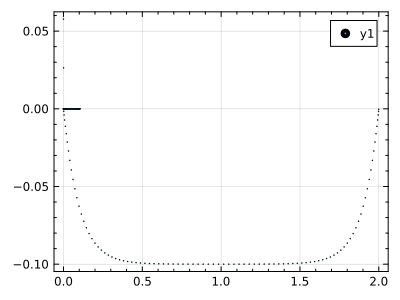

In [12]:
scatter(real.(qi[1:end]),imag.(qi[1:end]),markersize=0.5)

In [13]:
Vmat=zeros(ComplexF64,2*length(qi),2*length(qi));
Gmat=zeros(ComplexF64,2*length(qi),2*length(qi));
Tmat=zeros(ComplexF64,2*length(qi),2*length(qi));

In [14]:
function VMat!(E;Λ=0.5,Cv = 0.0,Cp=0.0,I=0,plist=qi,des=Vmat)
    getqw(E,Λ)

    for l in eachindex(plist)
        for m in eachindex(plist)
            i, j = 1, 1
            des[sublen*(i-1)+l, sublen*(j-1)+m] = potential_DnDsc(E,plist[l], plist[m]; Cv=Cv,Cp=Cp,I=I)
            i, j = 1, 2
            des[sublen*(i-1)+l, sublen*(j-1)+m] = potential_DDscross(E,plist[l], plist[m];  Cv=Cv,Cp=Cp,I=I)
            i, j = 2, 1
            des[sublen*(i-1)+l, sublen*(j-1)+m] = potential_DDscross(E,plist[l], plist[m];  Cv=Cv,Cp=Cp,I=I)
            i, j = 2, 2
            des[sublen*(i-1)+l, sublen*(j-1)+m] = potential_DcDsn(E,plist[l], plist[m];  Cv=Cv,Cp=Cp,I=I)
        end
    end
    return nothing
end

VMat! (generic function with 1 method)

In [15]:
VMat!(3.875)

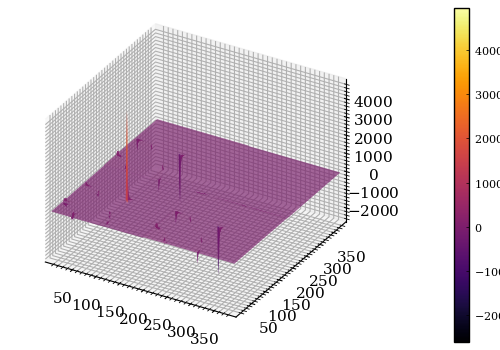

In [15]:
surface(collect(1:2*length(qi)),collect(1:2*length(qi)),[real(Vmat[x,y]) for y in 1:2*length(qi),x in 1:2*length(qi)])

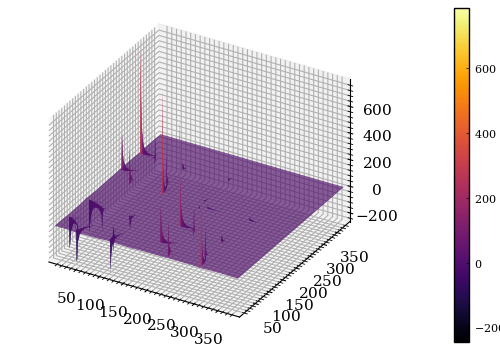

In [16]:
surface(collect(1:2*length(qi)),collect(1:2*length(qi)),[imag(Vmat[x,y]) for y in 1:2*length(qi),x in 1:2*length(qi)])

In [15]:
Gc(E,q)=1/(2π^2)/(E-mDn-mDsc-q^2/(2*μf(mDn,mDsc))+im*ΓDscf(E,q)/2)
Gn(E,q)=1/(2π^2)/(E-mDc-mDsn-q^2/(2*μf(mDc,mDsn))+im*ΓDsnf(E,q)/2)

Gn (generic function with 1 method)

In [16]:
function GMat!(E;Λ=0.5,qi=qi,wi=wi,des=Gmat)
    getqw(E,Λ)
    
    i=1
    for j in eachindex(wi)
        des[(i-1)*sublen+2+len+j,(i-1)*sublen+2+len+j]=wi[j]*qi[2+len+j]^2*Gc(E,qi[2+len+j])
    end
    
    i=2
    for j in eachindex(wi)
        des[(i-1)*sublen+2+len+j,(i-1)*sublen+2+len+j]=wi[j]*qi[2+len+j]^2*Gn(E,qi[2+len+j])
    end
    
    return nothing
end

GMat! (generic function with 1 method)

In [17]:
function detVG(E;Λ=0.5,Cv=0.0,Cp=0.0,I=0)
    VMat!(E;Λ=Λ,Cv=Cv,Cp=Cp,I=I)
    GMat!(E;Λ=Λ)
    return det(LinearAlgebra.I-Vmat*Gmat)
end

detVG (generic function with 1 method)

In [18]:
function TMat!(E;Λ=0.5,Cv=0.0,Cp=0.0,I=0,des=Tmat)
    VMat!(E;Λ=Λ,Cv=Cv,Cp=Cp,I=I)
    GMat!(E;Λ=Λ)
    try 
        des .=inv(LinearAlgebra.I-Vmat*Gmat)*Vmat
    catch
        error("Λ:$Λ; Cv:$Cv")
    end
    nothing
end

TMat! (generic function with 1 method)

In [20]:
@btime TMat!(3.875)

  92.584 ms (4671 allocations: 9.68 MiB)


In [21]:
let 
    function inv_abst(x;E=mDn+mDsc-273e-6,I=0)
        TMat!(E;Λ=x[1],I=I)
        return 1/abs(Tmat[1,1])
    end
    
    tmpf(x)=inv_abst(x)
    init_val=[0.5]
    lower=[0.3]
    upper=[1.2]
    res=Optim.optimize(tmpf,lower,upper,init_val)
    println(Optim.minimum(res))
    println(Optim.minimizer(res))
end

0.00019742905203882813
[0.39190584746707224]


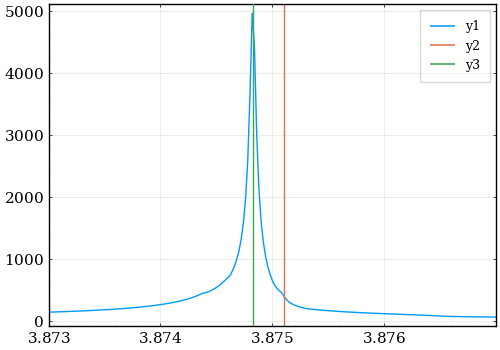

In [23]:
let Ev=collect(3.873:0.00002:3.877)
    function tmpf(E)
        TMat!(E;Λ=0.3919058474670764)
        abs(Tmat[1,1])
    end
    resv=[tmpf(e) for e in Ev]
    plot(Ev,resv,xlims=(3.873,3.877))
    vline!([mDn+mDsc])
    vline!([mDn+mDsc-273e-6])
end

# Extract pole position

In [19]:
function find_poles(pars)
    _lam,_Cv,_Cp=pars
    function f!(F, x)
        e, γ = x
        tmp = detVG(e + im * γ; Λ = _lam,Cv=_Cv,Cp=_Cp)
        F[1] = real(tmp)
        F[2] = imag(tmp)
    end
    tmp=NLsolve.nlsolve((F, x) -> f!(F, x), [mDn + mDsc - 333e-6, -24e-6])
    (tmp.zero[1]-mDn-mDsc)+im*tmp.zero[2]
end

find_poles (generic function with 1 method)

In [20]:
find_poles([0.3919058474670764,0.0,0.0])

-0.00027403403374792745 - 2.6153399025734216e-5im

In [23]:
3.8748259659662523-mDn-mDsc

-0.00027403403374792745

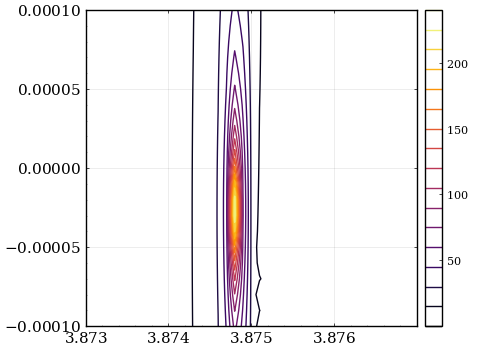

sys:1: UserWarning: The following kwargs were not used by contour: 'label'


In [27]:
let Ev=collect(3.873:0.0001:3.877),Γv=collect(-100e-6:10e-6:100e-6)
    resv=[1/abs(detVG(e+im*γ;Λ=0.3919058474670764)) for γ in Γv,e in Ev]
    contour(Ev,Γv,resv,fill=false)
end

# Fitting

In [22]:
using Interpolations;

In [23]:
function maketmatrixf(E)
    tmatrix=zeros(ComplexF64,len)
    tmp=zero(ComplexF64)
    for k in 3:(2+len)
        tmp=1.0
        for i in eachindex(wi)
            tmp+=wi[i]*qi[2+len+i]^2*Gc(E,qi[2+len+i])*Tmat[k,2+len+i]
            tmp+=-wi[i]*qi[2+len+i]^2*Gn(E,qi[2+len+i])*Tmat[k,sublen+2+len+i]
        end
        tmatrix[k-2]=tmp
    end
    return LinearInterpolation(real.(qi[3:2+len]),tmatrix)
end

maketmatrixf (generic function with 1 method)

In [24]:
function Γ3f(E;Λ = 0.5,Cv=0.0,Cp=0.0)
     TMat!(E;Λ = Λ,Cv=Cv,Cp=Cp)

    res = 0.0
    μ1, μ2 = μf(mDn, mDsc), μf(mDc, mDsn)
    m1,m2,m3=mDn,mπc,mDn

    tmptmatrixf = maketmatrixf(E)
    tmatrixf(p) = (real(qi[3]) <= p && p <= real(qi[2+len])) ? tmptmatrixf(p) : 0.0
    for i in eachindex(xxx)
        for j in eachindex(xxx)
            x1, x2, w1, w2 = xxx[i], xxx[j], www[i], www[j]
            s23=(m2+m3)^2*(1-x1)+(E-m1)^2*x1
            s12_min=m1^2+m2^2-(s23-E^2+m1^2)*(s23+m2^2-m3^2)/(2*s23)-sqrt(abs(λf(s23,E^2,m1^2)*λf(s23,m2^2,m3^2)))/(2*s23)
            s12_max=m1^2+m2^2-(s23-E^2+m1^2)*(s23+m2^2-m3^2)/(2*s23)+sqrt(abs(λf(s23,E^2,m1^2)*λf(s23,m2^2,m3^2)))/(2*s23)
            s12=s12_min*(1-x2)+s12_max*x2
            q,qbar=sqrt(λf(s23,mπc^2,mDn^2))/(2*sqrt(s23)),sqrt(λf(s12,mDn^2,mπc^2))/(2*sqrt(s12))
            p,pbar=sqrt(λf(E^2,mDn^2,s23))/(2*E),sqrt(λf(E^2,mDn^2,s12))/(2*E)
            res+=w1*w2*abs((E-m1)^2-(m2+m3)^2)*abs(s12_max-s12_min)*abs(q*tmatrixf(p)*Gc(E,p)+qbar*tmatrixf(pbar)*Gc(E,pbar))^2
        end
    end
    return res
end

Γ3f (generic function with 1 method)

In [25]:
function Resolution(E, E1)
    σ1 = 1.05 * 263e-6
    σ2 = 2.413 * σ1
    α = 0.778
    gaussfunc(x, μ, σ) = 1 / sqrt(2 * π) / σ * exp(-(x - μ)^2 / (2 * σ^2))
    return α * gaussfunc(E, E1, σ1) + (1 - α) * gaussfunc(E, E1, σ2)
end

Resolution (generic function with 1 method)

## fitting

In [26]:
using PyCall;
import NLsolve;
piminuit=pyimport("iminuit");

In [27]:
let 
    data_ddπ_sub_df = DataFrame(CSV.File("./data/ddpi_sub_du.csv", header = ["x", "y"]));
    len=length(data_ddπ_sub_df.x)
    len1=Int64(len/3)
    xv=[3.8731+0.0002*(i-1) for i in 1:20]
    yv=[data_ddπ_sub_df.y[3*(i-1)+2] for i in 1:len1]
    wv=[abs(data_ddπ_sub_df.y[3*(i-1)+1]-data_ddπ_sub_df.y[3*(i-1)+3])/2 for i in 1:len1]
    global const data_ddπ_sub=Data(xv,yv,wv);
    nothing
end

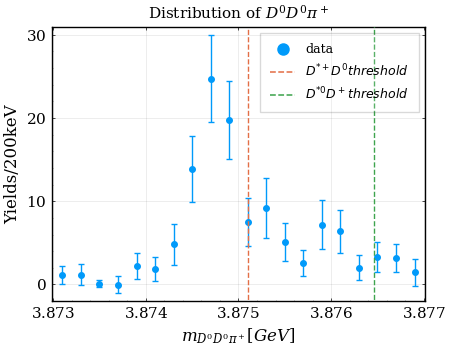

sys:1: UserWarning: You passed a edgecolor/edgecolors ((0.0, 0.6056031611752245, 0.9786801175696073, 1.0)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.


In [29]:
@plt_data data_ddπ_sub title = L"Distribution of $D^0D^0\pi^+$" xlabel = L"m_{D^0D^0\pi^+}[GeV]" ylabel = "Yields/200keV" label = "data" size = (450, 350)
vline!([mDn + mDsc], ls = :dash, label = L"D^{*+}D^0 threshold")
vline!([mDc + mDsn], ls = :dash, label = L"D^{*0}D^+ threshold")

In [28]:
mutable struct distr
    Λ::Float64
    Cv::Float64
    Cp::Float64
    Γ3::Vector{Float64}
end

In [29]:
let Λ = 0.3919058474670764,Cv=0.0,Cp=0.0,Ev = range(3.873, 3.877, 100)
    resv = [Γ3f(e; Λ = Λ,Cv=Cv,Cp=Cp) for e in Ev]
    global distr_inst = distr(Λ,Cv,Cp, resv)
end

distr(0.3919058474670764, 0.0, 0.0, [0.0034027260913155363, 0.0036978748129866384, 0.004021836992733997, 0.004377530907803514, 0.0047692515509833834, 0.005200842394746931, 0.005677872165174815, 0.006206118202678755, 0.006791372804790664, 0.007441557832886541  …  0.620374905868245, 0.6218677942424711, 0.6658379661743139, 0.5881466879449245, 0.5670971307924182, 0.6316860402829347, 0.5790083498189411, 0.5249585491144481, 0.5800249077950925, 0.5900880500356366])

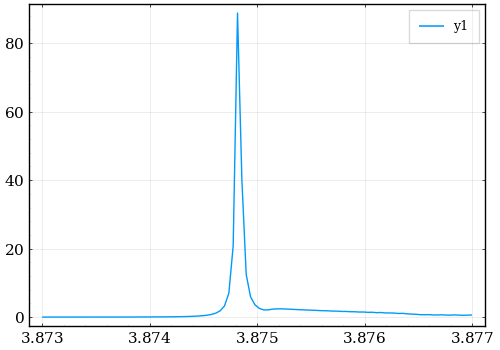

In [33]:
plot(range(3.873, 3.877, 100),distr_inst.Γ3)

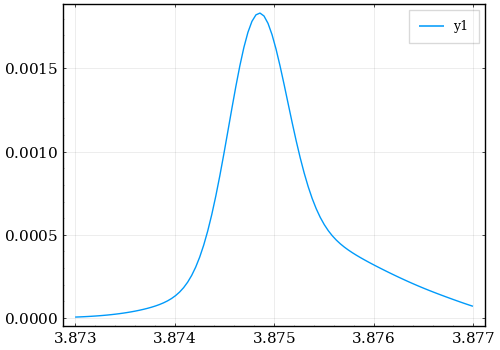

In [34]:
let
    Ev = range(3.873, 3.877, 100)
    Emin, Emax = Ev[1], Ev[end]
    tmpΓ3f = LinearInterpolation(Ev, distr_inst.Γ3)
    
    tmpf(E) = quadgauss(x ->(Emax - Emin) * tmpΓ3f(Emin + (Emax - Emin) * x) * Resolution(Emin + (Emax - Emin) * x, E), xxx, www)

    ΔE=0.0002
    Ebin(E,x)=(E-ΔE/2)*(1-x)+(E+ΔE/2)*x 
    tmpf1(E)=quadgauss(x->ΔE*tmpf(Ebin(E,x)),xxx,www)
    plot(Ev,tmpf1.(Ev))
end

In [30]:
function remake_distr(dis::distr, Λ,Cv,Cp)
    if Λ ≈ dis.Λ&&Cv≈dis.Cv&&Cp≈dis.Cp
        return false
    else
        Ev = range(3.873, 3.877, 100)
        for i in eachindex(dis.Γ3)
            dis.Γ3[i] = Γ3f(Ev[i];Λ = Λ,Cv=Cv,Cp=Cp)
        end
        dis.Λ = Λ
        dis.Cv=Cv 
        dis.Cp=Cp
    end
    return true
end

remake_distr (generic function with 1 method)

In [31]:
function dist(E, pars; dis = distr_inst, xx = xxx, ww = www)
    N, Λ,Cv,Cp = pars
    remake_distr(dis, Λ,Cv,Cp)
    Ev = range(3.873, 3.877, 100)
    Emin, Emax = Ev[1], Ev[end]
    tmpΓ3f = LinearInterpolation(Ev, dis.Γ3)
    
    tmpf(E) = quadgauss(x ->(Emax - Emin) * tmpΓ3f(Emin + (Emax - Emin) * x) * Resolution(Emin + (Emax - Emin) * x, E), xx, ww)

    ΔE=0.0002
    Ebin(E,x)=(E-ΔE/2)*(1-x)+(E+ΔE/2)*x
    return N * quadgauss(x->ΔE*tmpf(Ebin(E,x)),xx,ww)
end

dist (generic function with 1 method)

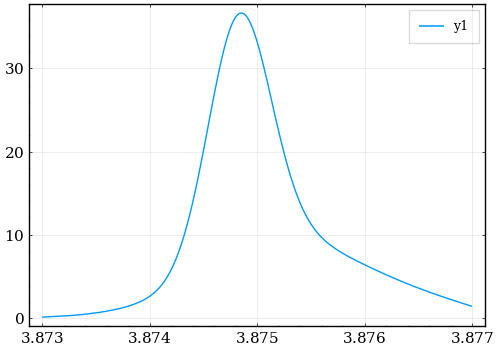

In [38]:
plot(e->dist(e,[1,0.3919058474670764,0.0,0.0])*30/0.0015,3.873,3.877)

In [32]:
fcn(x,y,z,l; fitrange = ()) = chisq(dist, data_ddπ_sub,[x,y,z,l]; fitrange = fitrange)

fcn (generic function with 1 method)

## fitting results

In [39]:
30/0.0015

20000.0

In [40]:
let 
    _n,_lam,_Cv,_Cp=[10000,0.3919058474670764,0.0,0.0]
    tmp_model=piminuit.Minuit(fcn,N=_n,lam=_lam,cv=_Cv,cp=_Cp,name=("N","lam","cv","cp"))
    set!(tmp_model.limits,"N",(5000,12000))
    set!(tmp_model.limits,"lam",(0.3,0.5))
    set!(tmp_model.fixed,"cv",true)
    set!(tmp_model.fixed,"cp",true)
    global fitres=piminuit.Minuit.migrad(tmp_model) 
end

PyObject <FMin algorithm='Migrad' edm=9.740355160084461e-06 edm_goal=0.0002 errordef=1.0 fval=14.690700051344047 has_accurate_covar=True has_covariance=True has_made_posdef_covar=False has_parameters_at_limit=False has_posdef_covar=True has_reached_call_limit=False has_valid_parameters=True hesse_failed=False is_above_max_edm=False is_valid=True nfcn=59 ngrad=0 reduced_chi2=nan time=1283.7937708339887>
(Param(number=0, name='N', value=10144.360987610333, error=1088.8166513397646, merror=None, is_const=False, is_fixed=False, lower_limit=5000.0, upper_limit=12000.0), Param(number=1, name='lam', value=0.3961418688992543, error=0.0009692806589594316, merror=None, is_const=False, is_fixed=False, lower_limit=0.3, upper_limit=0.5), Param(number=2, name='cv', value=0.0, error=0.1, merror=None, is_const=False, is_fixed=True, lower_limit=None, upper_limit=None), Param(number=3, name='cp', value=0.0, error=0.1, merror=None, is_const=False, is_fixed=True, lower_limit=None, upper_limit=None))
[[1.23813348e+06 2.67817851e-01 0.00000000e+00 0.00000000e+00]
 [2.67817851e-01 9.39534463e-07 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]]

In [41]:
print(fitres.values)

PyObject <ValueView N=10144.360987610333 lam=0.3961418688992543 cv=0.0 cp=0.0>

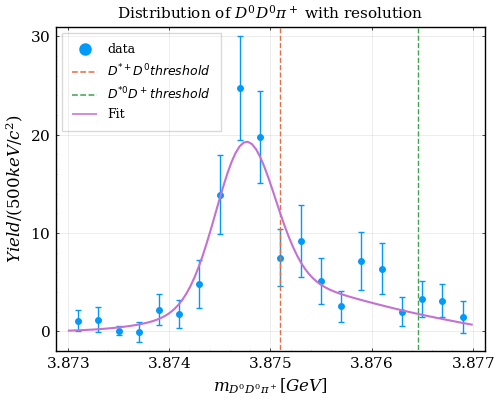

sys:1: UserWarning: You passed a edgecolor/edgecolors ((0.0, 0.6056031611752245, 0.9786801175696073, 1.0)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: You passed a edgecolor/edgecolors ((0.0, 0.6056031611752245, 0.9786801175696073, 1.0)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: You passed a edgecolor/edgecolors ((0.0, 0.6056031611752245, 0.9786801175696073, 1.0)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
sys:1: UserWarning: No data for colormapping provided via 'c'

In [42]:
let
    Ev = range(3.873, 3.877, 100)
    @plt_data data_ddπ_sub title = L"Distribution of $D^0D^0\pi^+$ with resolution" xlabel = L"m_{D^0D^0\pi^+}[GeV]" ylabel = L"Yield/(500keV/c^2)" label = "data" size = (500, 400) legend = :topleft
    vline!([mDn + mDsc], ls = :dash, label = L"D^{*+}D^0 threshold")
    vline!([mDc + mDsn], ls = :dash, label = L"D^{*0}D^+ threshold")
    plot!(Ev, e -> dist(e, [10144.361483353334,0.3961418693268329,0.0,0.0]), lw = 1.5, label = "Fit")
end

In [43]:
find_poles([0.3961418693268329,0.0,0.0])

-0.00035042516959338244 - 2.459852927096692e-5im

In [53]:
3.874749574830407-mDn-mDsc

-0.00035042516959338244

In [62]:
14.69/19

0.773157894736842

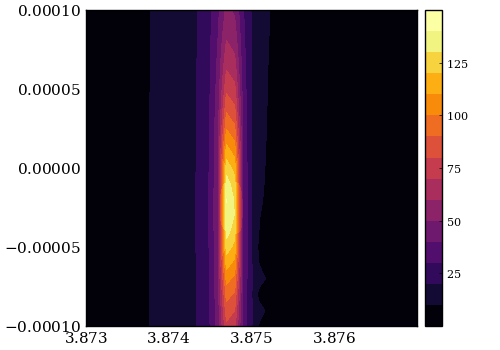

In [54]:
let Ev=collect(3.873:0.0001:3.877),Γv=collect(-100e-6:10e-6:100e-6)
    resv=[1/abs(detVG(e+im*γ;Λ=0.3961418693268329)) for γ in Γv,e in Ev]
    contour(Ev,Γv,resv,fill=true)
end

In [55]:
14.69/(20-1)

0.773157894736842

In [58]:
print(fitres.errors)

PyObject <ErrorView N=1088.8164699385534 lam=0.0009692805508922098 cv=0.1 cp=0.1>

In [63]:
find_poles([0.3961418693268329+0.0009692805508922098,0.0,0.0])-find_poles([0.3961418693268329,0.0,0.0])

-1.8163189503983546e-5 + 3.0544666698204847e-7im

In [64]:
find_poles([0.3961418693268329-0.0009692805508922098,0.0,0.0])-find_poles([0.3961418693268329,0.0,0.0])

1.8285018412722565e-5 - 2.328926003819375e-7im

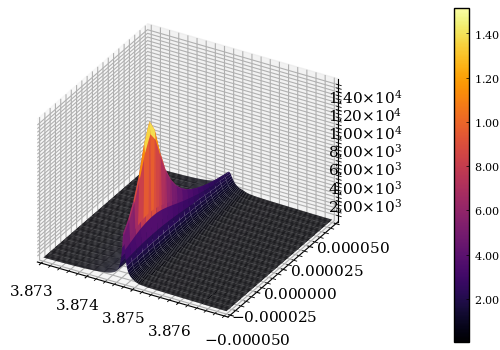

In [65]:
let Ev=collect(3.873:0.00002:3.877),Γv=collect(-50e-6:5e-6:50e-6)
    function tmpf(E)
        TMat!(E;Λ=0.3961418693268329)
        abs(Tmat[1,1])
    end
    resv=[real(tmpf(e+im*γ)) for γ in Γv,e in Ev]
    surface(Ev,Γv,resv)
end

# Get data

In [28]:
Ev=collect(3.873:0.00002:3.877);
Γv=collect(-50e-6:5e-6:50e-6);

In [29]:
let 
    function tmpf(E)
        TMat!(E;Λ=0.3961418693268329)
        abs(Tmat[1,1])
    end
    global tsq_v=[tmpf(e+im*γ) for γ in Γv,e in Ev]
end

21×201 Matrix{Float64}:
 149.912  151.234  152.585  153.968  …  59.5958  59.2715  58.9534  58.6413
 149.918  151.24   152.592  153.975     59.6902  59.363   59.0421  58.7274
 149.923  151.245  152.597  153.98      59.7845  59.4543  59.1307  58.8134
 149.926  151.249  152.601  153.984     59.8785  59.5455  59.2191  58.8785
 149.929  151.251  152.603  153.987     59.9724  59.6365  59.3074  58.9642
 149.931  151.253  152.605  153.988  …  60.0662  59.7273  59.3955  59.0498
 149.931  151.253  152.605  153.989     60.1597  59.818   59.4834  59.1352
 149.93   151.252  152.605  153.988     60.253   59.9084  59.5506  59.2205
 149.928  151.251  152.603  153.986     60.3461  59.9986  59.6382  59.3055
 149.925  151.247  152.6    153.983     60.439   60.0887  59.7256  59.314
 149.921  151.243  152.595  153.978  …  60.5331  60.1594  59.8128  59.3988
 149.916  151.238  152.59   153.973     60.6255  60.2491  59.9012  59.4848
 149.91   151.232  152.583  153.966     60.7176  60.3385  59.9116  59.5692
 1

In [51]:
gr(frame=:box, minorticks=5, size=(500,350), fontfamily="DejaVu Sans",titlefontsize=11
    ,guidefontsize=12,tickfontsize=11,legendfontsize=9,
    bg_color_legend = RGBA(1,1,1,0.15), markerstrokecolor= :auto);

In [52]:
surface(Ev,Γv .*10^6,tsq_v,legend=false,zlabel=L"|T_{D^0D^{*+}\rightarrow D^0D^{*+}}|",frame=false,zticks=false,grid=false,
xlabel=L"\Re E[GeV]",ylabel=L"\Im E[keV]")
savefig("./images/tmatrix.pdf")

"/Users/qiulin/Nutstore Files/Nutstore/Projects/gitrepos/Tcc/LSE/images/tmatrix.pdf"

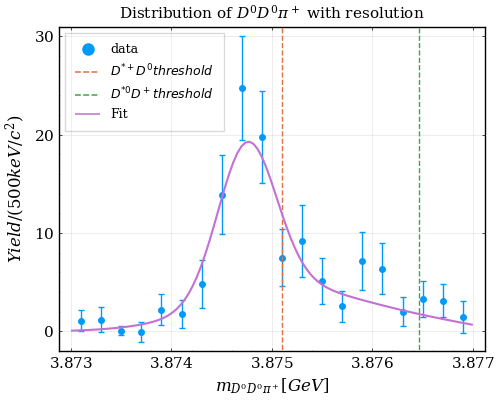

In [56]:
let
    Ev = range(3.873, 3.877, 100)
    @plt_data data_ddπ_sub title = L"Distribution of $D^0D^0\pi^+$ with resolution" xlabel = L"m_{D^0D^0\pi^+}[GeV]" ylabel = L"Yield/(500keV/c^2)" label = "data" size = (500, 400) legend = :topleft
    vline!([mDn + mDsc], ls = :dash, label = L"D^{*+}D^0 threshold")
    vline!([mDc + mDsn], ls = :dash, label = L"D^{*0}D^+ threshold")
    plot!(Ev, e -> dist(e, [10144.361483353334,0.3961418693268329,0.0,0.0]), lw = 1.5, label = "Fit")
end

In [57]:
let Ev = range(3.873, 3.877, 100)
    yields=[dist(e, [10144.361483353334,0.3961418693268329,0.0,0.0]) for e in Ev]
    df=DataFrame(X=Ev,Y=yields)
    CSV.write("./output/fit3.csv",df)
end

"./output/fit3.csv"

# Test Lambda

In [27]:
fitresΛ=Array{Any}(undef,10);

In [29]:
for i in 1:10
    _n,_lam,_Cv,_Cp=[10000,0.3+0.1*(i-1),0.5,0.5]
    tmp_model=piminuit.Minuit(fcn,N=_n,lam=_lam,cv=_Cv,cp=_Cp,name=("N","lam","cv","cp"))
    set!(tmp_model.limits,"N",(2000,20000))
    set!(tmp_model.limits,"cv",(0.0,1.0))
    set!(tmp_model.limits,"cp",(0.0,1.0))
    set!(tmp_model.fixed,"lam",true)
#     set!(tmp_model.fixed,"cp",true)
    fitresΛ[i]=piminuit.Minuit.migrad(tmp_model)
end

In [36]:
[fitresΛ[i].fval for i in 1:10]

10-element Vector{Float64}:
  72.89168105572996
  15.880340390356602
  15.11080214115897
 112.3762421888704
  68.79147219558054
  66.80940372022494
  65.9251977529496
  65.69036678376847
  65.68907604304822
  65.69574598603326

In [56]:
[fitresΛ[i].values for i in 1:10]

10-element Vector{PyObject}:
 PyObject <ValueView N=16587.30938015855 lam=0.3 cv=2.2686487139941293e-07 cp=0.9999999711197984>
 PyObject <ValueView N=8702.392766887373 lam=0.4 cv=0.10326297274151867 cp=0.9392990217632153>
 PyObject <ValueView N=6268.1185885734585 lam=0.5 cv=0.395935693896095 cp=0.42577456908103206>
 PyObject <ValueView N=2000.001028994959 lam=0.6000000000000001 cv=0.5019496006614703 cp=0.47529510643004746>
 PyObject <ValueView N=19999.999990016273 lam=0.7 cv=0.48883206969786197 cp=0.007667183753983858>
 PyObject <ValueView N=19999.999506555134 lam=0.8 cv=0.5519476140726226 cp=0.03946124700388359>
 PyObject <ValueView N=19999.991920642904 lam=0.9000000000000001 cv=0.5859485125980622 cp=0.08648475288502167>
 PyObject <ValueView N=19999.999998418527 lam=1.0 cv=0.6292015702742113 cp=0.46194837447998516>
 PyObject <ValueView N=19093.40673534565 lam=1.1 cv=0.6219930616711027 cp=0.2922149289557646>
 PyObject <ValueView N=18531.46919166752 lam=1.2 cv=0.6251042729535217 cp=0.30

In [44]:
fitresΛ[10].values

PyObject <ValueView N=18531.46919166752 lam=1.2 cv=0.6251042729535217 cp=0.3075338838321157>

In [46]:
find_poles([1.2,0.6251042729535217,0.3075338838321157])

-0.0025740984647404375 - 2.0613107944339347e-5im

In [50]:
fitresΛ[4]

PyObject <FMin algorithm='Migrad' edm=7.499953401651047e-05 edm_goal=0.0002 errordef=1.0 fval=112.3762421888704 has_accurate_covar=False has_covariance=True has_made_posdef_covar=True has_parameters_at_limit=True has_posdef_covar=False has_reached_call_limit=False has_valid_parameters=True hesse_failed=False is_above_max_edm=False is_valid=True nfcn=76 ngrad=0 reduced_chi2=nan time=1900.6446749280003>
(Param(number=0, name='N', value=2000.001028994959, error=30.288407847343024, merror=None, is_const=False, is_fixed=False, lower_limit=2000.0, upper_limit=20000.0), Param(number=1, name='lam', value=0.6000000000000001, error=0.006000000000000001, merror=None, is_const=False, is_fixed=True, lower_limit=None, upper_limit=None), Param(number=2, name='cv', value=0.5019496006614703, error=0.004812213092711598, merror=None, is_const=False, is_fixed=False, lower_limit=0.0, upper_limit=1.0), Param(number=3, name='cp', value=0.47529510643004746, error=0.06086702638597638, merror=None, is_const=False, is_fixed=False, lower_limit=0.0, upper_limit=1.0))
[[ 1.24736471e-01  0.00000000e+00 -3.53004871e-08 -3.99741076e-07]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-3.53004871e-08  0.00000000e+00  2.31581099e-05  2.93053625e-04]
 [-3.99741076e-07  0.00000000e+00  2.93053625e-04  3.72328711e-03]]

In [52]:
let 
    _n,_lam,_Cv,_Cp=[10000,0.6,0.5,0.5]
    tmp_model=piminuit.Minuit(fcn,N=_n,lam=_lam,cv=_Cv,cp=_Cp,name=("N","lam","cv","cp"))
    set!(tmp_model.limits,"N",(0,50000))
    set!(tmp_model.limits,"cv",(0.0,1.0))
    set!(tmp_model.limits,"cp",(0.0,1.0))
#     set!(tmp_model.fixed,"cv",true)
    set!(tmp_model.fixed,"lam",true)
    global fitres=piminuit.Minuit.migrad(tmp_model) 
end

PyObject <FMin algorithm='Migrad' edm=2.8795754525693727e-05 edm_goal=0.0002 errordef=1.0 fval=86.99901209448807 has_accurate_covar=False has_covariance=True has_made_posdef_covar=True has_parameters_at_limit=False has_posdef_covar=False has_reached_call_limit=False has_valid_parameters=True hesse_failed=False is_above_max_edm=False is_valid=True nfcn=123 ngrad=0 reduced_chi2=nan time=6654.130121933005>
(Param(number=0, name='N', value=1177.2447647581412, error=354.74775407121916, merror=None, is_const=False, is_fixed=False, lower_limit=0.0, upper_limit=50000.0), Param(number=1, name='lam', value=0.6, error=0.006, merror=None, is_const=False, is_fixed=True, lower_limit=None, upper_limit=None), Param(number=2, name='cv', value=0.5075489222115505, error=0.014212302750022443, merror=None, is_const=False, is_fixed=False, lower_limit=0.0, upper_limit=1.0), Param(number=3, name='cp', value=0.40500755420364987, error=0.17539352006860348, merror=None, is_const=False, is_fixed=False, lower_limit=0.0, upper_limit=1.0))
[[ 1.25937924e+05  0.00000000e+00 -6.34636478e-01 -4.97340676e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-6.34636478e-01  0.00000000e+00  2.02043985e-04  2.54028446e-03]
 [-4.97340676e+00  0.00000000e+00  2.54028446e-03  3.21691201e-02]]

In [53]:
fitres.values

PyObject <ValueView N=1177.2447647581412 lam=0.6 cv=0.5075489222115505 cp=0.40500755420364987>

In [54]:
find_poles([0.6,0.5075489222115505,0.40500755420364987])

-0.0009060139571794856 - 1.9771910577252334e-5im

In [55]:
let 
    _n,_lam,_Cv,_Cp=[10000,0.5,0.5,0.5]
    tmp_model=piminuit.Minuit(fcn,N=_n,lam=_lam,cv=_Cv,cp=_Cp,name=("N","lam","cv","cp"))
    set!(tmp_model.limits,"N",(0,50000))
    set!(tmp_model.limits,"cv",(0.0,1.0))
    set!(tmp_model.limits,"cp",(0.0,1.0))
    set!(tmp_model.limits,"lam",(0.3,1.2))
#     set!(tmp_model.fixed,"cv",true)
#     set!(tmp_model.fixed,"lam",true)
    global fitres=piminuit.Minuit.migrad(tmp_model) 
end

PyObject <FMin algorithm='Migrad' edm=1.7949463487124908e-05 edm_goal=0.0002 errordef=1.0 fval=14.579266054806343 has_accurate_covar=False has_covariance=True has_made_posdef_covar=True has_parameters_at_limit=True has_posdef_covar=False has_reached_call_limit=False has_valid_parameters=True hesse_failed=False is_above_max_edm=False is_valid=True nfcn=622 ngrad=0 reduced_chi2=nan time=17114.410824884995>
(Param(number=0, name='N', value=2965.749266471167, error=325.6728941501001, merror=None, is_const=False, is_fixed=False, lower_limit=0.0, upper_limit=50000.0), Param(number=1, name='lam', value=1.1902530473426371, error=0.0027006184515341314, merror=None, is_const=False, is_fixed=False, lower_limit=0.3, upper_limit=1.2), Param(number=2, name='cv', value=0.6967488781065975, error=0.024217046124765385, merror=None, is_const=False, is_fixed=False, lower_limit=0.0, upper_limit=1.0), Param(number=3, name='cp', value=0.013489546780068843, error=0.9855667940401891, merror=None, is_const=False, is_fixed=False, lower_limit=0.0, upper_limit=1.0))
[[ 1.06089727e+05 -1.78981760e-02 -1.15526458e-01  3.29950336e-01]
 [-1.78981760e-02  7.29538432e-06 -5.92630851e-08  1.60433791e-07]
 [-1.15526458e-01 -5.92630851e-08  5.87008734e-04  7.41794481e-03]
 [ 3.29950336e-01  1.60433791e-07  7.41794481e-03  9.41683930e-02]]

# Test $C_V$

In [39]:
fitres_V1=Array{Any}(undef,11);

In [61]:
# for i in 1:11
#     println(i)
#     _n,_lam,_Cv,_Cp=[10000,1.0,0.1*(i-1),0.0]
#     tmp_model=piminuit.Minuit(fcn,N=_n,lam=_lam,cv=_Cv,cp=_Cp,name=("N","lam","cv","cp"))
# #     set!(tmp_model.limits,"N",(10000,30000))
# #     set!(tmp_model.limits,"lam",(0.3,0.5))
#     set!(tmp_model.fixed,"cv",true)
#     set!(tmp_model.fixed,"cp",true)
#     fitres_V1[i]=piminuit.Minuit.migrad(tmp_model) 
# end

In [61]:
df_cv=DataFrame(CSV.File("./output/df_cv.csv", header = ["Λ", "cv","cp","chi2","δΛ"]))

Row,Λ,cv,cp,chi2,δΛ
,Float64,Float64,Float64,Float64,Float64
1,0.396144,0.0,0.0,14.6907,0.0010708
2,0.406574,0.05,0.0,14.7925,9.35406e-6
3,0.418013,0.1,0.0,14.8565,0.00106976
4,0.427908,0.15,0.0,16.0446,0.00091588
5,0.443976,0.2,0.0,14.967,0.00103724
6,0.458998,0.25,0.0,15.0305,3.87699e-5
7,0.475823,0.3,0.0,15.0499,0.00108523
8,0.491791,0.35,0.0,16.1788,0.00103412
9,0.513466,0.4,0.0,16.2047,0.00128803


In [64]:
# plotlyjs();
gr(frame=:box, minorticks=5, size=(500,350),titlefontsize=11
    ,guidefontsize=12,tickfontsize=11,legendfontsize=9,
    bg_color_legend = RGBA(1,1,1,0.15), markerstrokecolor= :auto);

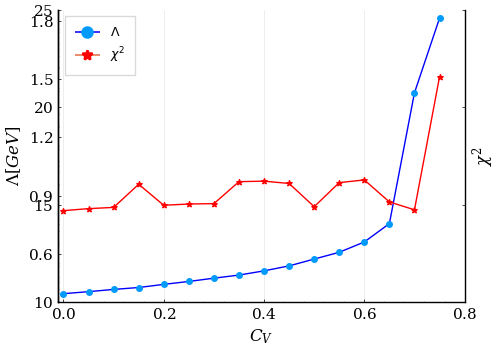

In [72]:
plot(df_cv.cv[1:16],df_cv.Λ[1:16],xlabel=L"C_V",ylabel=L"\Lambda[GeV]",label=L"\Lambda"
    ,legend=:topleft,xlims=[-0.01,0.8],lc=:blue,markershape=:circle)
plot!(df_cv.cv[1:16],fill(NaN,16),label=L"\chi^2",markercolor=:red,markershape=:star5)
plot!(twinx(),df_cv.cv[1:16],df_cv.chi2[1:16],ylabel=L"\chi^2",
    legend=false,xlims=[-0.01,0.8],ylims=[10,25],lc=:red,
    markercolor=:red,markershape=:star5)
# savefig("./images/depcv.pdf")

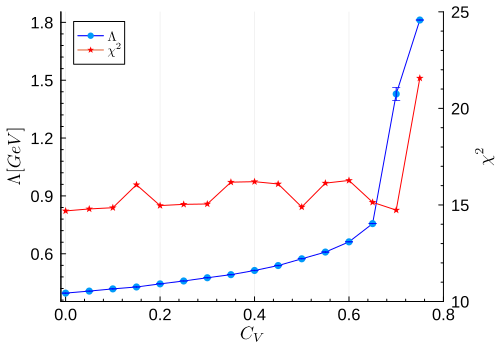

In [44]:
# plot(df_cv.cv[1:16],df_cv.Λ[1:16],yerror=df_cv.δΛ[1:16],xlabel=L"C_V",ylabel=L"\Lambda[GeV]",label=L"\Lambda"
#     ,legend=:topleft,xlims=[-0.01,0.8],lc=:blue,markershape=:circle)
# plot!(df_cv.cv[1:16],fill(NaN,16),label=L"\chi^2",markercolor=:red,markershape=:star5)
# plot!(twinx(),df_cv.cv[1:16],df_cv.chi2[1:16],ylabel=L"\chi^2",
#     legend=false,xlims=[-0.01,0.8],ylims=[10,25],lc=:red,
#     markercolor=:red,markershape=:star5)

In [48]:
find_poles([df_cv.Λ[1],df_cv.cv[1],0.0])|>println
find_poles([df_cv.Λ[1]+df_cv.δΛ[1],df_cv.cv[1],0.0])|>println
find_poles([df_cv.Λ[1]-df_cv.δΛ[1],df_cv.cv[1],0.0])|>println

-0.00035047020721235 - 2.459798078281399e-5im
-0.0003706134778971304 - 2.4272475441563625e-5im
-0.0003302917383085635 - 2.48560917130416e-5im


In [40]:
df_poles=[]

Any[]

In [49]:
for i in 1:16
    push!(df_poles,[find_poles([df_cv.Λ[i],df_cv.cv[i],0.0]),
            find_poles([df_cv.Λ[i]+df_cv.δΛ[i],df_cv.cv[i],0.0]),
            find_poles([df_cv.Λ[i]-df_cv.δΛ[i],df_cv.cv[i],0.0])])
end

In [60]:
df_poles[16]

3-element Vector{ComplexF64}:
  -0.0004175475326406719 - 1.6453336392751087e-5im
  -0.0004176022869892826 - 1.645291765495086e-5im
 -0.00041749278241498544 - 1.645375522928085e-5im

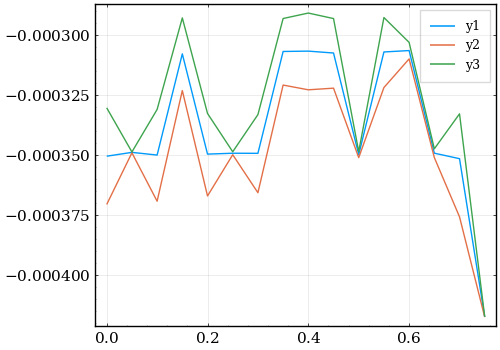

In [73]:
plot(df_cv.cv[1:16],real.([df_poles[i][1] for i in 1:16]))
plot!(df_cv.cv[1:16],real.([df_poles[i][2] for i in 1:16]))
plot!(df_cv.cv[1:16],real.([df_poles[i][3] for i in 1:16]))

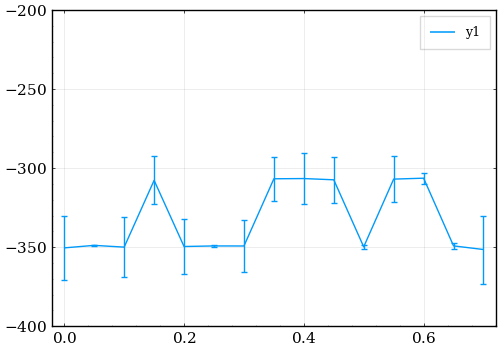

In [74]:
plot(df_cv.cv[1:15],real.([df_poles[i][1] for i in 1:15]) .*1e6,yerror=real.([abs(df_poles[i][2]-df_poles[i][3])/2 for i in 1:15] .*1e6)
    ,ylims=(-400,-200))

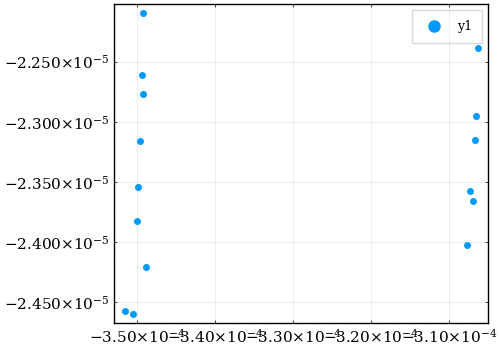

In [75]:
scatter(real.([df_poles[i][1] for i in 1:15]),imag.([df_poles[i][1] for i in 1:15]))

In [76]:
for i in 1:16
    if df_cv.chi2[i]<15
        println(df_poles[i])
    end
end

ComplexF64[-0.00035047020721235 - 2.459798078281399e-5im, -0.0003706134778971304 - 2.4272475441563625e-5im, -0.0003302917383085635 - 2.48560917130416e-5im]
ComplexF64[-0.00034887801947913744 - 2.4207583267773954e-5im, -0.0003490514178032811 - 2.4205796179027278e-5im, -0.0003487046551615691 - 2.42093715525122e-5im]
ComplexF64[-0.0003499985580126541 - 2.382122694917114e-5im, -0.0003692517704343423 - 2.357539437201051e-5im, -0.0003309684821477532 - 2.40190857274806e-5im]
ComplexF64[-0.0003495996611810881 - 2.3162220382856e-5im, -0.0003670637401222976 - 2.2908284857154576e-5im, -0.00033264245507913515 - 2.3521973657509328e-5im]
ComplexF64[-0.0003498174195413206 - 2.3543181097524612e-5im, -0.00035107168746195683 - 2.3529551298943624e-5im, -0.0003485645961669448 - 2.3556874259969835e-5im]
ComplexF64[-0.00035150998742006223 - 2.4573513763404968e-5im, -0.00037578564601714604 - 2.4562517021197783e-5im, -0.0003328066772652072 - 2.4861185114298816e-5im]


# Test Cv (from constrained parameters)

In [21]:
df_pre_paras=DataFrame(CSV.File("./output/review_lamv_Cv.csv"));

In [22]:
pre_Cv=df_pre_paras.Cv;
pre_Λv=df_pre_paras.lam;

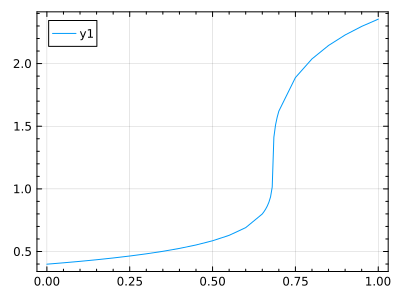

In [23]:
plot(pre_Cv,pre_Λv)

In [24]:
fitres_V3=Array{Any}(undef,30);

In [65]:
for i in 16:20
    println(i)
    _n,_lam,_Cv,_Cp=[10000,pre_Λv[i],pre_Cv[i],0.0]
    tmp_model=piminuit.Minuit(fcn,N=_n,lam=_lam,cv=_Cv,cp=_Cp,name=("N","lam","cv","cp"))
#     set!(tmp_model.limits,"N",(10000,30000))
    set!(tmp_model.limits,"lam",(0.9*_lam,1.1*_lam))
    set!(tmp_model.fixed,"cv",true)
    set!(tmp_model.fixed,"cp",true)
    fitres_V3[i]=piminuit.Minuit.migrad(tmp_model) 
end

16
17
18
19
20


In [66]:
[fitres_V3[i].values[2] for i in 1:20]

20-element Vector{Float64}:
 0.3961485172214738
 0.4066515265830028
 0.4180132990797983
 0.4303871312635053
 0.44397360977794803
 0.4590059837458011
 0.4758239606380141
 0.5023733239233835
 0.5249172095683712
 0.5515411479056322
 0.5840893917955103
 0.6138215286198236
 0.6840325252049282
 0.8010189688057328
 0.8183003523803343
 0.8378001028292028
 0.8617485085638024
 0.8909375061615867
 0.9302954119505329
 0.9958295668213073

BoundsError: BoundsError: attempt to access 33-codeunit String at index [1:37]

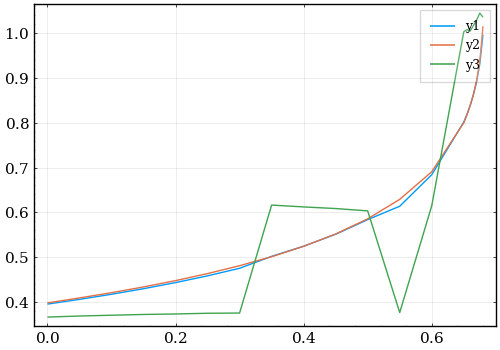

In [83]:
plot(pre_Cv[1:20],[fitres_V3[i].values[2] for i in 1:20])
plot!(pre_Cv[1:20],pre_Λv[1:20])
plot!(pre_Cv[1:20],[fitres_V3[i].fval/40 for i in 1:20])

In [67]:
[fitres_V3[i].fval for i in 1:20]

20-element Vector{Float64}:
 14.690698602320445
 14.784908575417901
 14.856466116344553
 14.923179058143917
 14.967018180513454
 15.030518968794537
 15.049859452632571
 24.65678568396321
 24.49320459634824
 24.349016661981672
 24.14003660101615
 15.094720636333587
 24.594018516199913
 40.07783876742548
 40.270485783610866
 40.14362648194767
 40.62824576052734
 41.109866994803966
 41.743606488293516
 41.369201919669734

BoundsError: BoundsError: attempt to access 12-codeunit String at index [1:32]

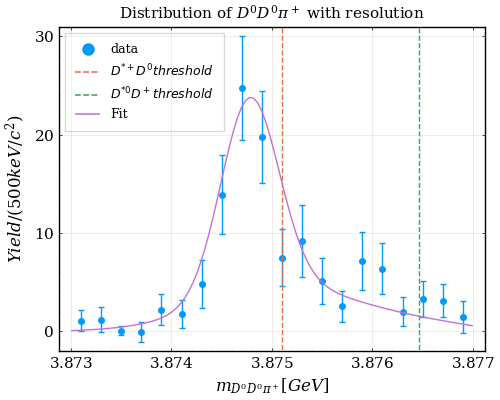

KeyError: KeyError: key "usage_request" not found

In [79]:
let nf=13
    Ev = range(3.873, 3.877, 100)
    @plt_data data_ddπ_sub title = L"Distribution of $D^0D^0\pi^+$ with resolution" xlabel = L"m_{D^0D^0\pi^+}[GeV]" ylabel = L"Yield/(500keV/c^2)" label = "data" size = (500, 400) legend = :topleft
    vline!([mDn + mDsc], ls = :dash, label = L"D^{*+}D^0 threshold")
    vline!([mDc + mDsn], ls = :dash, label = L"D^{*0}D^+ threshold")
    plot!(Ev, e -> dist(e, [fitres_V3[nf].values[1],fitres_V3[nf].values[2]-0.02,pre_Cv[nf],0.0]), lw = 1.0, label = "Fit")
    # plot!(Ev, e -> dist(e, [fitres_V3[nf].values[1],pre_Λv[nf],pre_Cv[nf],0.0]),lw = 1.0, label = "Fit")
end

## poles from constrained parameters

In [37]:
for i in 1:30
    println(find_poles([pre_Λv[i],pre_Cv[i],0.0]))
end

-0.0004034257284684095 - 2.3872082266206743e-5im
-0.00041055556507796354

 - 2.3488381608021803e-5im


-0.0004151082269996387 - 2.3051600493625243e-5im
-0.00041996537636102005

 - 2.2734440549053807e-5im


-0.0004258062625366321 - 2.217134894003626e-5im
-0.000432284875373945

...

 - 1.2990953350510651e-5im


-0.0007433965466949743 - 1.3782974908120175e-5im
-0.0007869587576077031

 - 1.438400081342484e-5im


-0.0008259880848204837 - 1.4868106766313944e-5im
-0.0008611616527876009

 - 1.527244008411521e-5im


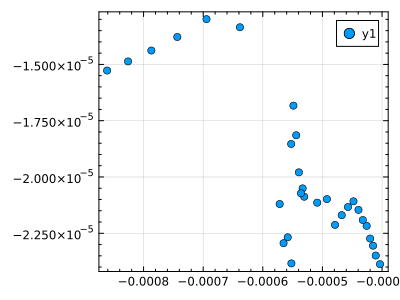

In [38]:
let 
    poles_v=[find_poles([pre_Λv[i],pre_Cv[i],0.0]) for i in 1:30]
    scatter(real.(poles_v),imag.(poles_v))
end

0.5521466255187986    0.45


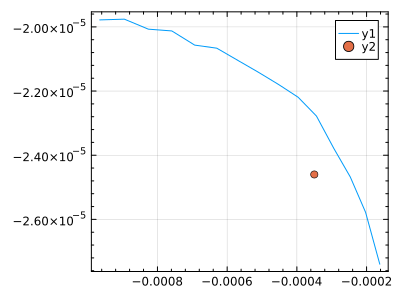

In [25]:
let nf=10
    println(pre_Λv[nf],"    ",pre_Cv[nf])
    xv=collect(range(pre_Λv[nf-1],pre_Λv[nf+1],15))
    poles_v=[find_poles([x,pre_Cv[nf],0.0]) for x in xv]
    plot(real.(poles_v),imag.(poles_v))
    scatter!([-350e-6],[-24.6e-6])
end

In [26]:
function getqw(E,Λ;ω=0.1,V0=-0.06,qi=qi,wi=wi)
    pmax=sqrt(abs(λf(E^2,mDn^2,(mπc+mDn)^2)))/(2*E)
    qi[1],qi[2]=qon_c(E),qon_0(E)
    for i in eachindex(xxx)
        qi[2+i]=pmax*xxx[i]
        qi[2+len+i]=Γsmcx(xxx[i],Λ,ω,V0)
        wi[i]=dΓsmcx(xxx[i],Λ,ω,V0)*www[i]
    end
    nothing
end

getqw (generic function with 1 method)

0.5521466255187986    0.45


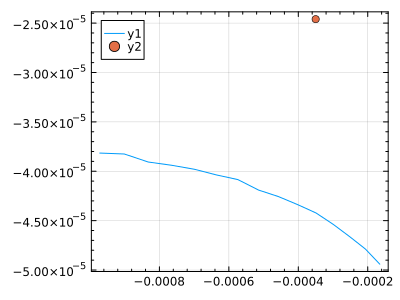

In [27]:
let nf=10
    println(pre_Λv[nf],"    ",pre_Cv[nf])
    xv=collect(range(pre_Λv[nf-1],pre_Λv[nf+1],15))
    poles_v=[find_poles([x,pre_Cv[nf],0.0]) for x in xv]
    plot(real.(poles_v),imag.(poles_v))
    scatter!([-350e-6],[-24.6e-6])
end